<a href="https://colab.research.google.com/github/atikhasan007/DeepLearning/blob/main/pytorch/15_transfer_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

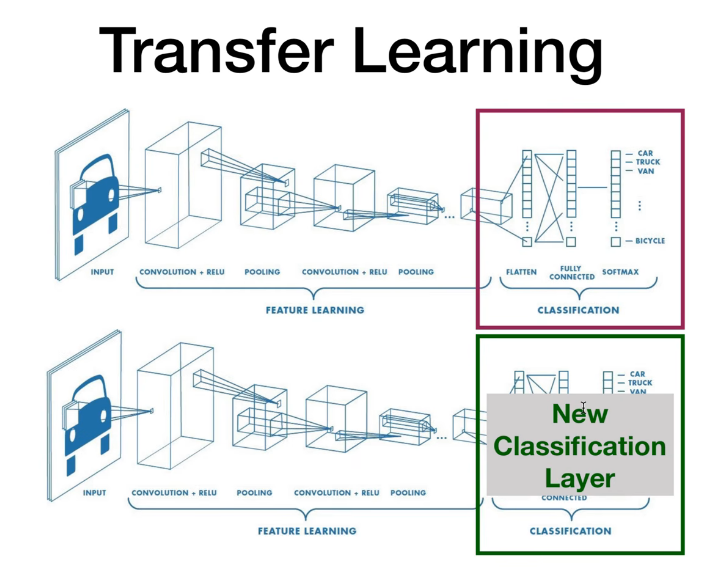

In [50]:
# Transfer Learning হলো এমন একটা technique যেখানে তুমি একটা আগে থেকে
# train করা (pretrained) model নিয়ে সেটা নতুন problem solve করার জন্য ব্যবহার করো।


# With Transfer Learning
#  Model A-এর knowledge নিয়ে আসো
#  শুধু last layer change করো




In [51]:
# ImageFolder
# Scheduler
# Transfer Learning

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
import copy


In [52]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [53]:
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])


In [57]:
# PyTorch-এর data augmentation + preprocessing pipeline
# Pixel value standardize করে:
# Normalize
#  model training stable হয়
#  fast convergence হয়
#  better accuracy

data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(), # image (PIL/NumPy) → PyTorch tensor
        transforms.Normalize(mean, std)
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])
}

In [58]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ajayrana/hymenoptera-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'hymenoptera-data' dataset.
Path to dataset files: /kaggle/input/hymenoptera-data


In [61]:
from torch.utils.data import DataLoader
# import data
data_dir = '/kaggle/input/hymenoptera-data/hymenoptera_data'
sets = ['train', 'val']


# train এবং val দুইটার জন্য আলাদা dataset বানাচ্ছে
# ImageFolder -> folder structure দেখে automatically label assign করে

image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val']}


# DataLoader -> dataset থেকে batch আকারে data দেয়
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                              shuffle=True, num_workers=0)
               for x in ['train', 'val']}


dataset_size = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes
print(class_names)

['ants', 'bees']


In [63]:
def train_model(model, criterion, optimizer, scheduler , num_epochs=25):
  # setup part
  since = time.time() # training কত সময় লাগলো সেটা measure করার জন্য
  best_model_wts = copy.deepcopy(model.state_dict()) # best model save করার জন্য (initially current model)
  best_acc = 0.0 # সর্বোচ্চ validation accuracy track করে



# epoch loop

  for epoch in range(num_epochs):
    print(f"Epoch {epoch}/{num_epochs-1}")
    print('-'*10)


    # Each epoch has a training and validation phase
    for phase in ['train', 'val']:
      if phase == 'train':
        model.train() # set model to training mode
      else:
        model.eval() # set model to evaluate mode

        # Loss & accuracy reset
        runing_loss = 0.0
        running_corrects = 0



        # iterate ove data
        for inputs, labels in dataloaders[phase]:
          inputs = inputs.to(device)
          labels = labels.to(device)


          # forward pass + prediction
          # track history if only in train

          with torch.set_grad_enabled(phase == 'train'):
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)


            # backward + optimize only if in training phase
            if phase == 'train':
              optimizer.zero_grad()
              loss.backward()
              optimizer.step()

          # statistics update
          # পুরো epoch এর loss + accuracy জমা হচ্ছে
          runing_loss += loss.item() * inputs.size(0)
          running_corrects += torch.sum(preds == labels.data)

        # Scheduler step
        if phase == 'train':
          scheduler.step()


        #Epoch result
        epoch_loss = runing_loss / dataset_size[phase]
        epoch_acc = running_corrects.double() / dataset_size[phase]


        print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")


        # deep copy the model
        if phase == 'val' and epoch_acc > best_acc:
          best_acc = epoch_acc
          best_model_wts = copy.deepcopy(model.state_dict())
      print()

    # Training summary print
    time_elapsed = time.time() - since
    print(f"Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    print(f"Best val Acc: {best_acc:4f}")


    # load best model weights
    model.load_state_dict(best_model_wts)
    return model







Trasnfer Learning

In [64]:
# basically একটা pretrained ResNet18 দিয়ে transfer learning
# করে binary classification training সেটআপ
# Image classification model
# শেষ layer change করে 2 class output
# pretrained=True -> ImageNet dataset এ আগে থেকেই train করা weights use করা হচ্ছে




model = models.resnet18(pretrained=True)
# find Final layer input size
num_ftrs = model.fc.in_features

model.fc = nn.Linear(num_ftrs, 2) # 512 -> 2
model.to(device)


# loss function

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001)

# scheduler
# প্রতি 7 epoch পর learning rate কমবে
step_lr_scheduler = lr_scheduler.StepLR(
    optimizer,
    step_size=7,
    gamma=0.1)
# Training call
model = train_model(model,
                    criterion,
                    optimizer,
                    step_lr_scheduler,
                    num_epochs=20)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 186MB/s]


Epoch 0/19
----------

val Loss: 0.7299 Acc: 0.5163

Training complete in 0m 2s
Best val Acc: 0.516340


fine tuning

In [65]:
#  Pretrained ResNet18 নেওয়া হয়েছে
#  পুরো backbone freeze করা হয়েছে
#  শুধু শেষ layer train করা হয়েছে

model = models.resnet18(pretrained=True)
for param in model.parameters():
  param.requires_grad = False

num_ftrs = model.fc.in_features

model.fc = nn.Linear(num_ftrs, 2)
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001)

# scheduler
step_lr_scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

model = train_model(model,
                    criterion,
                    optimizer,
                    step_lr_scheduler,
                    num_epochs=20)


Epoch 0/19
----------

val Loss: 0.6920 Acc: 0.5817

Training complete in 0m 1s
Best val Acc: 0.581699
